# Dependency imports

In [1]:
import torch
from torchvision.models import resnet152

from Training.library import validate
from Training.training import Config, TrainingResources, initClassifierTrainers, trainingLoop
import Training.metrics as m
import Training.plotting as plots

# *modelname* specific configuration

eg.: ResNet-152

In [2]:
c = Config("boilerplate")

#Configure execution to needs
c.purge    = False
c.training = True
c.loadBest = False

#Set hyperparams to model
c.learningRate = 1e-4
c.weightDecay  = 1e-3

#c.numClasses = 8
c.batchSize = 16
c.workers = 8


# Initialize resources

In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

model = resnet152(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, c.numClasses)

TR = TrainingResources(c, model, initClassifierTrainers, device)
TR.load(c)

print(TR.criterion)
print(TR.optimizer)

#Note: After this point only some config changes will apply

Using cuda device
CrossEntropyLoss()
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.001
)


# Execute training

In [4]:
# Override training related config if neccesary
c.training = True
c.gpuSleep = 10
c.trainingEpochs = 20

trainingLoop(c, TR, stopAt=3)

display(TR.history)

Epoch 1/3 	| 

KeyboardInterrupt: 

# Plots of learning process

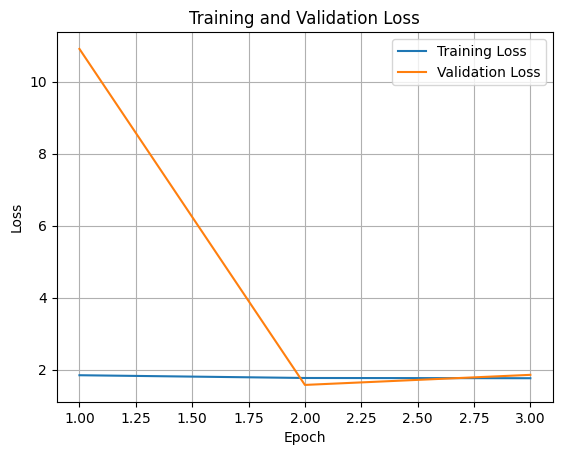

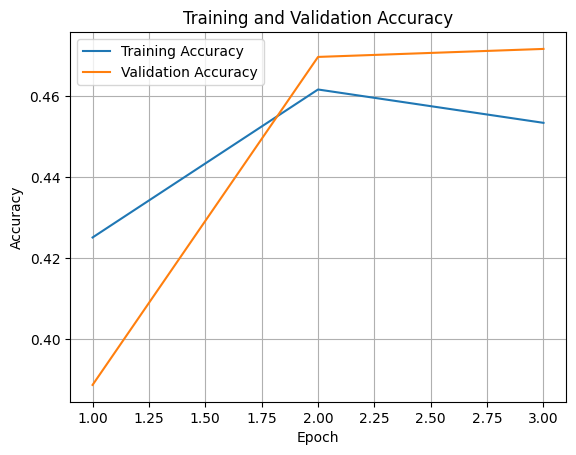

In [ ]:
plots.plotTraining(TR.history, TR.plotsFolder)

# Metrics of best model on test data

### Evaluate on test set

In [ ]:
#Reload weights with best validation
c.loadBest = True

TR.load(c)

#Evaluate on test set
test_loss, test_acc, CM = validate(TR.model, TR.test_loader, TR.criterion, device)

print(f"Test loss: {test_loss} \t | Test acc: {test_acc}")

Loaded state
Test loss: 1.8766146159782184 	 | Test acc: 0.4582677165354331


### Plots of test results

Models/ResNet-152/plots


,Actinic keratoses,Basal cell carcinoma,Benign keratosis-like lesions,Dermatofibroma,Melanocytic nevi,Melanoma,Squamous cell carcinoma,Vascular lesions
Actinic keratoses,7,8,2,0,7,7,2,0
Basal cell carcinoma,45,188,118,14,267,117,44,8
Benign keratosis-like lesions,0,2,0,0,4,0,0,0
Dermatofibroma,0,0,0,0,0,0,0,0
Melanocytic nevi,6,35,71,6,782,142,7,10
Melanoma,30,100,72,5,228,187,11,8
Squamous cell carcinoma,0,0,0,0,0,0,0,0
Vascular lesions,0,0,0,0,0,0,0,0


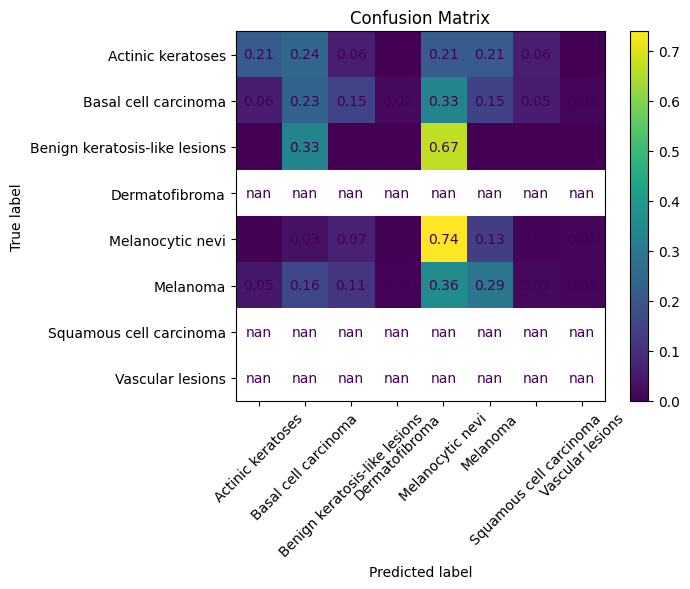

,accuracy,precision,recall,f1
Actinic keratoses,95.7874,21.2121,7.9545,11.5702
Basal cell carcinoma,70.1575,23.4707,56.4565,33.1570
Benign keratosis-like lesions,89.4094,0.0000,0.0000,0.0000
Dermatofibroma,99.0157,0.0000,0.0000,0.0000
Melanocytic nevi,69.1732,73.8432,60.7143,66.6383
Melanoma,71.6535,29.1732,41.2804,34.1865
Squamous cell carcinoma,97.4803,0.0000,0.0000,0.0000
Vascular lesions,98.9764,0.0000,0.0000,0.0000


In [ ]:
print(TR.plotsFolder)

display(CM)
plots.plotConfusionMatrix(CM, TR.plotsFolder)

metrics = plots.deriveMetrics(CM, TR.plotsFolder)
display(metrics)

### Inspection using captum